In [1]:
from tensorflow.keras import backend as K
K.clear_session()

In [2]:
!pip install rarfile

In [3]:
import os
import pandas as pd
import gdown
import rarfile
import shutil
from PIL import Image
# Download the RAR file
url = 'https://drive.google.com/uc?id=1sRuV2_o399bVaMUajLVXINkZoE1bD8Gk'
#https://drive.google.com/file/d/1g3EkPk0jPOVxHnsd4BqoRLZoznfFkdeC/view?usp=sharing
output_rar = '/content/Train_Augumented_Dataset_Leguminosae_3C_Dataset.rar'
gdown.download(url, output_rar, quiet=False)
# Extract the RAR file
with rarfile.RarFile(output_rar, 'r') as rar_ref:
    rar_ref.extractall('/content')

Downloading...
From (original): https://drive.google.com/uc?id=1sRuV2_o399bVaMUajLVXINkZoE1bD8Gk
From (redirected): https://drive.google.com/uc?id=1sRuV2_o399bVaMUajLVXINkZoE1bD8Gk&confirm=t&uuid=d7268db5-b3ed-4da4-9873-4bf1bfc77c93
To: /content/Train_Augumented_Dataset_Leguminosae_3C_Dataset.rar
100%|██████████| 96.7M/96.7M [00:01<00:00, 88.8MB/s]


In [4]:
# Path to the extracted dataset folder

dataset = '/content/Train_Augumented_Dataset_Leguminosae_3C_Dataset'

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Add, GlobalAveragePooling2D, Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define the CNN architecture
input_shape = (224, 224, 3)
num_classes = 4

# Input
inputs = layers.Input(shape=input_shape)
# LLF Net#1
a1 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(inputs)
a1 = layers.BatchNormalization()(a1)
a1 = layers.Activation('swish')(a1)
MPa1 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(a1)

b1 = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(inputs)
b1 = layers.BatchNormalization()(b1)
b1 = layers.Activation('swish')(b1)
a1b1 = layers.Concatenate()([MPa1,b1])
a1b1=layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same')(a1b1)

a2=layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(a1b1)
a2 = layers.BatchNormalization()(a2)
a2 = layers.Activation('swish')(a2)
MPa2 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(a2)

b2 = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(a1b1)
b2 = layers.BatchNormalization()(b2)
b2 = layers.Activation('swish')(b2)

c1 = layers.Conv2D(32, (5, 5), strides=(4, 4), padding='same')(inputs)
c1 = layers.BatchNormalization()(c1)
c1 = layers.Activation('swish')(c1)
c1a2b2 = layers.Concatenate()([c1,MPa2,b2])

Net1=layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same')(c1a2b2)
####################################################################################
x1 = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(a1 )
x1 = layers.BatchNormalization()(x1)
x1 = layers.Activation('swish')(x1)
x1 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Activation('swish')(x1)

MPx1 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x1)
x2 = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(x1)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Activation('swish')(x2)
x1x2= layers.Concatenate()([MPx1,x2])
x1x2=layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same')(x1x2)

x3 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(x1x2)
x3 = layers.BatchNormalization()(x3)
x3 = layers.Activation('swish')(x3)

x4 = layers.Conv2D(64, (7, 1), strides=(1, 1), padding='same')(x1x2)
x4 = layers.Conv2D(64, (1, 7), strides=(1, 1), padding='same')(x4)
x4 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(x4)

x3x4= layers.Concatenate()([x3,x4])

Net2=layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same')(x3x4)
#####################################################################################
LLF=layers.Concatenate()([Net1,Net2])
#####################################################################################
Conv_MP_Block1 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(LLF)

x=Conv_MP_Block1
#####################################################################################
#####################################################################################

inception1_3 = Conv2D(128, (3, 3), activation='swish', padding='same')(x)

inception1_5 = Conv2D(64, (5, 5), activation='swish', padding='same')(x)


inception1_7 = Conv2D(64, (7, 7), activation='swish', padding='same')(x)

inc1_3_r2= Conv2D(64, (3, 3), dilation_rate=2, activation='swish', padding='same')(x)

inc1_3_r3= Conv2D(64, (3, 3), dilation_rate=3, activation='swish', padding='same')(x)

inception1_MP= MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
inception1_MP = Conv2D(128, (1, 1), activation='swish')(inception1_MP)
Inception_Block1_output = layers.Concatenate()([inception1_MP, inception1_3, inception1_5,inception1_7,inc1_3_r2,inc1_3_r3])
x = MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool')(Inception_Block1_output)
block_2=x
#####################################################################################
#####################################################################################

FB_MP= MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
Conv11_FB_MP = Conv2D(128, (1, 1), activation='swish')(FB_MP)
#######################################################
Conv11_1 = Conv2D(128, (1, 1), activation='swish')(x)
x_FB1 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(Conv11_1)
x_BN = layers.BatchNormalization()(x_FB1)
x_FB1 = layers.Activation('swish')(x_BN)

x_FB2 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(x_FB1)
x_BN = layers.BatchNormalization()(x_FB2)
x_FB2 = layers.Activation('swish')(x_BN)
Dense_Conc1=layers.Concatenate()([x_FB1, x_FB2])

x_FB3 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(Dense_Conc1)
x_BN = layers.BatchNormalization()(x_FB3)
x_FB3 = layers.Activation('swish')(x_BN)
Dense_Conc2=layers.Concatenate()([Dense_Conc1, x_FB3])
################################################################

Conv11_2 = Conv2D(128, (1, 1), activation='swish')(x)
x_FB1 = layers.Conv2D(32, (5, 5), strides=(1, 1), padding='same')(Conv11_1)
x_BN1 = layers.BatchNormalization()(x_FB1)
x_FB1 = layers.Activation('swish')(x_BN1)

x_FB2 = layers.Conv2D(32, (5, 5), strides=(1, 1), padding='same')(x_FB1)
x_BN = layers.BatchNormalization()(x_FB2)
x_FB2 = layers.Activation('swish')(x_BN)
Dense_Conc1=layers.Concatenate()([x_FB1, x_FB2])

x_FB3 = layers.Conv2D(32, (5, 5), strides=(1, 1), padding='same')(Dense_Conc1)
x_BN2 = layers.BatchNormalization()(x_FB3)
x_FB3 = layers.Activation('swish')(x_BN2)
Dense_Conc2=layers.Concatenate()([Dense_Conc1, x_FB3])


##############################################################
FB_Conc=layers.Concatenate()([Dense_Conc1, Dense_Conc2,Conv11_FB_MP])
FB_Conc= MaxPooling2D((2, 2), strides=(2, 2))(FB_Conc)
########################################################
# Global Average Pooling (GAP)
global_avg_pool1 = layers.GlobalAveragePooling2D()(FB_Conc)
global_avg_pool2 = layers.GlobalAveragePooling2D()(block_2)
global_avg_pool_conc = layers.Concatenate()([global_avg_pool1, global_avg_pool2])
# Fully Connected Layer
outputs = layers.Dense(num_classes, activation='softmax')(global_avg_pool_conc)
# Create the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 224, 224, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 224, 224, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 112, 112, 64)   │         36,928 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 112, 112, 64)   │            256 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_5 (Activation) │ (None, 112, 112, 64)   │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 112, 112, 64)   │         36,928 │ activation_5[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 112, 112, 64)   │            256 │ conv2d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 112, 112, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_6 (Activation) │ (None, 112, 112, 64)   │              0 │ batch_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 112, 112, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 56, 56, 64)     │         36,928 │ activation_6[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 64)   │              0 │ activation[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 112, 112, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 56, 56, 64)     │            256 │ conv2d_9[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concaten

 Total params: 1,591,460 (6.07 MB)

 Trainable params: 1,590,180 (6.07 MB)

 Non-trainable params: 1,280 (5.00 KB)

Found 3726 images belonging to 4 classes.
Found 87 images belonging to 4 classes.
Found 181 images belonging to 4 classes.
Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


117/117 ━━━━━━━━━━━━━━━━━━━━ 99s 474ms/step - accuracy: 0.6195 - loss: 0.8910 - val_accuracy: 0.3563 - val_loss: 2.0572
Epoch 2/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 32s 263ms/step - accuracy: 0.8424 - loss: 0.4172 - val_accuracy: 0.2529 - val_loss: 5.3574
Epoch 3/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 31s 266ms/step - accuracy: 0.8738 - loss: 0.3158 - val_accuracy: 0.2529 - val_loss: 7.9733
Epoch 4/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 31s 263ms/step - accuracy: 0.9172 - loss: 0.2314 - val_accuracy: 0.4138 - val_loss: 3.7560
Epoch 5/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 31s 265ms/step - accuracy: 0.9420 - loss: 0.1700 - val_accuracy: 0.8161 - val_loss: 0.5360
Epoch 6/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 41s 265ms/step - accuracy: 0.9519 - loss: 0.1465 - val_accuracy: 0.9540 - val_loss: 0.1317
Epoch 7/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 31s 265ms/step - accuracy: 0.9613 - loss: 0.1266 - val_accuracy: 0.8966 - val_loss: 0.2593
Epoch 8/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 31s 263ms/step - accuracy: 0.9629 - loss: 0.1089 - val

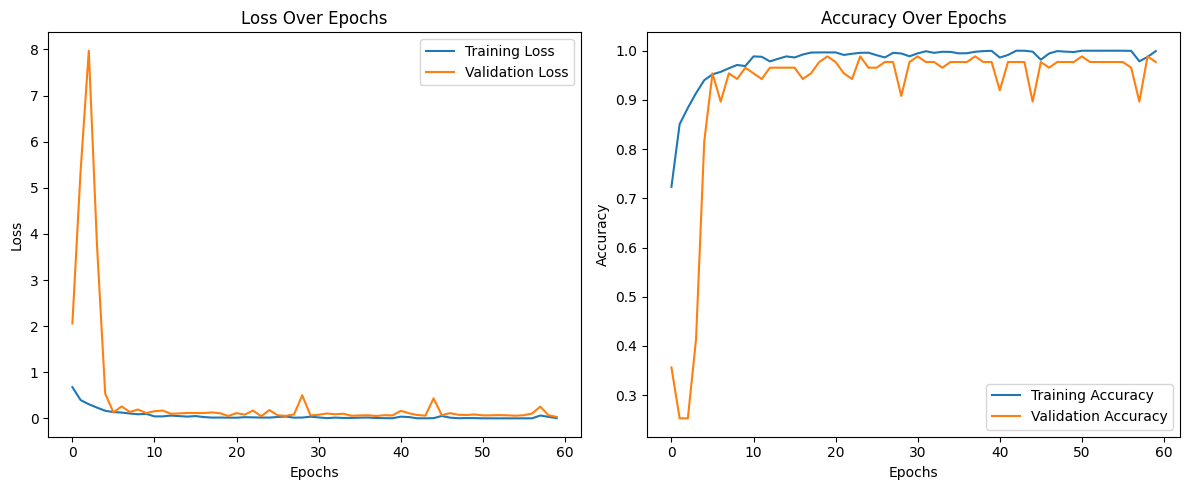

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

Performance on Test Data [Using Model_2-swish]
Precision: 0.9945952438145568
Recall: 0.994475138121547
F1 Score: 0.9944764162850815
Accuracy: 0.994475138121547
Confusion Matrix:
                      Acacia_Modesta  Albizia_Lebbeck  Bauhinia_Variegatav  \
Acacia_Modesta                   45                0                    0   
Albizia_Lebbeck                   0               43                    0   
Bauhinia_Variegatav               0                0                   45   
Unknown                           0                0                    1   

                     Unknown  
Acacia_Modesta             0  
Albizia_Lebbeck            0  
Bauhinia_Variegatav        0  
Unknown                   47  


In [6]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Add,
    GlobalAveragePooling2D, Flatten, Dense
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Directory for the dataset
data_dir = dataset

# ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data generators for training, validation, and testing
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'Train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, 'Validate'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'Test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# Training the model
history = model.fit(train_generator, epochs=60, validation_data=val_generator)

# Plot training results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Helper function to evaluate the model on given test generator
def evaluate_model(test_generator, model, classes, title="Performance"):
    y_test_pred = model.predict(test_generator)
    y_test_pred = np.argmax(y_test_pred, axis=1)

    precision = precision_score(test_generator.labels, y_test_pred, average='weighted')
    recall = recall_score(test_generator.labels, y_test_pred, average='weighted')
    f1 = f1_score(test_generator.labels, y_test_pred, average='weighted')
    accuracy = accuracy_score(test_generator.labels, y_test_pred)

    print(f"\n{title}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Accuracy:", accuracy)

    # Display the confusion matrix
    confusion = confusion_matrix(test_generator.labels, y_test_pred)
    confusion_df = pd.DataFrame(confusion, index=classes, columns=classes)
    print("Confusion Matrix:\n", confusion_df)

# Test the model on the test set
evaluate_model(test_generator, model, ['Acacia_Modesta', 'Albizia_Lebbeck', 'Bauhinia_Variegatav', 'Unknown'], title="Performance on Test Data [Using Model_2-swish]")
